# **24 · P4 추세검정 + APC — 상승은 '시대'의 효과이고, 세대 구배는 그 아래에 흐른다**

### **"MK 점추정 p=0.381(정직한 비유의) but P(S>0)=1.00 · 기간효과가 정렬추세와 r≥+0.96 · 코호트 구배 -0.891 — 추세의 정체를 연령·기간·코호트로 분해한다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 분석 단위 = **연도(2019~2025) × 응답자** · 방법 = **Mann-Kendall + Sen 기울기** / **HAPC-GLMM**(Yang & Land 2006) + **Intrinsic Estimator**(Yang·Fu·Land 2004)

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(구조 분해)** · CRISP-DM **P4(Modeling)** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 노트북 23이 정당화한 잠재평균 추세는 **통계적 단조 추세**인가 — 점추정 p값과 추정 불확실성(부트스트랩)을 각각 무엇이라 말하는가?
> **Q2.** 관측된 상승은 **연령(노화)·기간(시대)·코호트(세대구성 변화)** 중 무엇의 효과인가?
> **Q3.** 추세와 별개로 **세대(코호트) 구배**가 존재하는가 — 존재한다면 미래에 무엇을 시사하는가?

→ 노트북 23은 "추세를 비교해도 된다"(측정 정당성)까지 확보했다. 본 노트북은 그 추세가 **통계적으로 어떤 성격**인지(MK), 그리고 **누구의 효과**인지(APC)를 가른다 — 같은 상승도 노화 효과라면 인구구조 문제, 시대 효과라면 언론 환경 문제로 처방이 달라진다.

## **목차**

| § | 내용 | 핵심 질문 |
|:--:|------|-----------|
| 1 | 23이 남긴 두 질문 (+ DB①) | 왜 MK·왜 APC |
| 2 | 자기검증(MK 판정·APC 회복) | 직접구현을 믿어도 되나 |
| 3 | [발견] MK 추세검정 | p=0.381 vs P(S>0)=1.00 |
| 4 | 교차검정(단일문항·합성) | τ 부호 3종 일치 |
| 5 | APC 방법·식별 (+ DB②) | a+c=p를 어떻게 푸나 |
| 6 | [발견] APC 분해 | 기간 주도 + 코호트 구배 |
| 7 | [시각화] 3효과 프로파일 | 형상 비교 |
| 8~10 | 검증·종합·코드리뷰 (+ DB③) | 입증·경계 |

> **thin 원칙**: 로직은 `src/trend_apc.py`(SSOT)가 정본(`alignment.py` 재사용). 본 노트북은 단계함수(`self_validation`·`mann_kendall`·`sens_slope`·`mk_with_uncertainty`·`make_apc_frame`·`hapc_mixed`·`intrinsic_estimator`)를 호출해 *중간 산출*만 보일 뿐 로직을 재구현하지 않는다.
> ⚠️ **검증 게이트**: 수치는 KPF 원자료 재검증(`data-spec.md §6`) 전 보고서·웹데모 직접 인용 신중(DB③).
> **종합 문서(SSOT)**: [trend-apc-results.md](../docs/design/trend-apc-results.md) · 선행: [alignment-trust-trend.md](../docs/design/alignment-trust-trend.md)(23) · [mgcfa-invariance-results.md](../docs/design/mgcfa-invariance-results.md)(21)


In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "trend_apc.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

warnings.filterwarnings("ignore")
get_ipython().run_line_magic("matplotlib", "inline")  # 인라인 렌더(Agg 미사용 정책)
import matplotlib.pyplot as plt
from matplotlib import font_manager
def _kfont():
    for nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
        try:
            font_manager.findfont(nm, fallback_to_default=False)
            plt.rcParams["font.family"] = nm; break
        except Exception: continue
    plt.rcParams["axes.unicode_minus"] = False
_kfont()

import trend_apc as T     # 추세검정+APC SSOT (alignment.py 재사용)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

panel = pd.read_parquet(T.PARQUET)
assert len(panel) == 90996, f"행수 불일치: {len(panel):,}"
print(f"패널 {len(panel):,}행 · 연도 {sorted(panel['year'].unique())}")
print(f"추세 대상 = 정렬 잠재평균(23) · 교차검정 = trust_news_overall·cred_mean({T.CORE3})")
print(f"APC 입력 = age·birth_cohort (5년군) × period(1년) · 산출변수 = cred_mean(1~5)")

패널 90,996행 · 연도 [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
추세 대상 = 정렬 잠재평균(23) · 교차검정 = trust_news_overall·cred_mean(['cred_fair', 'cred_professional', 'cred_accurate'])
APC 입력 = age·birth_cohort (5년군) × period(1년) · 산출변수 = cred_mean(1~5)


## **1. [전제] 노트북 23이 남긴 두 질문**

23의 결론은 "비동등 2.4% ≤ 20% → **잠재평균 추세를 비교해도 된다**"였다. 이는 *측정의 정당성*이지 *추세의 성격*이 아니다. 남은 질문 둘:

**질문 A — 이것은 통계적 추세인가?** 7개 점(2019~2025)이 우상향으로 보여도, n=7에서 "단조 증가"가 우연으로 나올 확률은 작지 않다. 게다가 패턴이 비단조(2024 저점)라 눈대중은 더 위험하다.

**질문 B — 상승의 정체는 무엇인가?** 반복횡단면의 연도 차이는 세 성분이 뒤섞인 것이다:
- **연령(Age)** 효과 — 생애주기: 나이 들수록 신뢰가 변하는가
- **기간(Period)** 효과 — 시대: 그 해의 언론 환경·사건이 모두를 움직였는가
- **코호트(Cohort)** 효과 — 세대: 태어난 시대가 새긴 지속적 성향인가

표본의 연령구성이 해마다 다르면(01: 2022 최고령), **연령·코호트 효과가 "가짜 추세"로 둔갑**할 수 있다. 상승이 진짜 시대 효과인지 확인해야 23의 추세 해석이 완성된다.

### **Decision Box ① — 추세검정: OLS 회귀가 아니라 Mann-Kendall + Sen인 이유**

**기준: n=7, 비단조 패턴, 분포 가정 불가 조건에서 정직한 검정은 무엇인가.**

| 대안 | 가정 | 기각/채택 사유 |
|------|------|------|
| (a) OLS 연도회귀 | 잔차 정규성·등분산 | ❌ n=7에서 검증 불가능한 가정 + 이상연도 1개에 기울기가 휘둘림 |
| (b) 단순 종점차(2019 vs 2025) | 없음 | ❌ 중간연도 정보 폐기 — 비단조 패턴에서 과대해석 위험 |
| (c) **Mann-Kendall + Sen** | 무가정(순위 기반) | ✅ **채택** — 모든 연도쌍의 부호만 사용, **n≤8은 순열 정확분포 p**(근사 아님), Sen 기울기는 중앙값이라 이상연도에 강건 |

**+ 불확실성 전파**: 표준 MK는 α̂ 7개를 "관측값"으로 취급하지만, 각 α̂ 자체가 추정치(SE 보유)다. 정렬 부트스트랩(B=150) 각 복원표본에 MK를 적용해 **τ의 분포와 P(S>0)** 를 함께 보고한다 — 점추정 p와 추정 불확실성을 분리해 정직하게 말하기 위함이다.

## **2. 자기검증 — MK 판정과 APC 회복 (직접구현의 면허)**

- **MK**: 단조증가/평탄/단조감소 시뮬 → 부호·유의 판정이 정확한가 (증가·감소는 p<.05, 평탄은 p>.10이어야)
- **APC**: 알려진 연령(선형)·기간(단조증가)·코호트(세대 하락) 효과로 데이터를 생성 → IE가 기간효과 형상을 회복(corr>0.95)하는가

In [2]:
ok = T.self_validation()
assert ok, "자기검증 실패 - 이후 결과 해석 보류"
print("\n[자기검증 PASS] MK 판정(증가/감소/평탄) 정확 · IE가 알려진 기간효과 형상 회복")

◆ 자기검증


  [MK] 증가 S=21 p=0.0004 | 감소 S=-21 p=0.0004 | 평탄 p=0.7726 → OK


  [APC] IE 기간효과 회복 corr=0.9963 (rank_ok=True) → OK

[자기검증 PASS] MK 판정(증가/감소/평탄) 정확 · IE가 알려진 기간효과 형상 회복


**관찰**: 단조 시뮬에서 MK가 정확히 유의(p<.05), 평탄에서 비유의(p>.10) — 판정 오류 없음. APC 시뮬에서는 연령·기간·코호트를 **섞어 생성**했는데도 IE가 기간효과 형상을 corr>0.95로 회복(rank_ok=True) — 5년군(연령·코호트) vs 1년(기간) **간격차 식별**이 실데이터 규모에서 작동함을 확인했다.

**자기검증 — 완료**

## **3. [발견] MK 추세검정 — 점추정 p=0.381은 비유의, 추정 불확실성 반영 시 P(S>0)=1.00**

정렬 잠재평균 7개 점(23과 동일 파이프라인 점추정)에 MK 정확검정·Sen 기울기를 적용하고, 부트스트랩 α 분포(B=150)에 MK를 전파한다.

In [3]:
years, alpha = T.latent_trend_points(panel)
mk_lat = T.mann_kendall(alpha)
sen_lat = T.sens_slope(alpha, years)
print("정렬 잠재평균(2019~2025):", np.round(alpha, 3).tolist())
print(f"Mann-Kendall: S={mk_lat['S']} tau={mk_lat['tau']:+.3f} z={mk_lat['z']:+.3f} "
      f"정확 p={mk_lat['p_exact']:.4f}")
print(f"Sen 기울기 = {sen_lat:+.4f} /년 (2019-SD 단위)")

taus, s_pos, alpha_boot = T.mk_with_uncertainty(panel, B=150)
print(f"\n[불확실성 전파] 부트스트랩 tau 평균={taus.mean():+.3f} "
      f"(95% [{np.percentile(taus,2.5):+.3f}, {np.percentile(taus,97.5):+.3f}]) | "
      f"P(S>0)={s_pos:.3f}")

정렬 잠재평균(2019~2025): [0.0, 0.354, 0.474, 0.453, 0.394, 0.298, 0.671]
Mann-Kendall: S=7 tau=+0.333 z=+0.901 정확 p=0.3813
Sen 기울기 = +0.0595 /년 (2019-SD 단위)



[불확실성 전파] 부트스트랩 tau 평균=+0.415 (95% [+0.333, +0.524]) | P(S>0)=1.000


**관찰 — 두 층위를 분리해 정직하게 말한다**:

1. **점추정 층위**: S=7, τ=+0.333, **정확 p=0.3813 → 비유의**. n=7에서 비단조 패턴(2021~2024 등락)이 끼면 MK 검정력은 낮다. 이 p값을 숨기거나 "추세 있음"으로 눙치지 않는다.
2. **추정 불확실성 층위**: 그러나 α̂들은 상수가 아니라 추정치다. 부트스트랩 150개 복원표본 **전부에서 S>0** — 즉 "**증가 방향이라는 판단** 자체는 표집 변동에 흔들리지 않는다"(P(S>0)=1.00, τ 95% CI [+0.333, +0.524] 전 구간 양수).

종합하면: "**n=7 점추정으로는 단조 추세를 유의 판정할 수 없으나, 방향이 증가라는 것은 견고하다**" — 크기(Sen +0.0595/년)는 참고치, 결론의 무게는 방향에 둔다(DB③).

## **4. 교차검정 — 측정을 바꿔도 τ의 부호가 같은가**

잠재추세(모형 산출)에만 의존하지 않도록, 모형이 다른 두 지표 — 단일문항 `trust_news_overall`(2020~2025)·합성 `cred_mean`(3지표 평균, 2019~2025) — 에 같은 MK를 적용한다.

                     지표        구간   tau  정확 p  Sen기울기(/년)
                정렬 잠재평균 2019~2025 0.333 0.381       0.060
단일문항 trust_news_overall 2020~2025 0.467 0.272       0.028
           합성 cred_mean 2019~2025 0.143 0.773       0.028


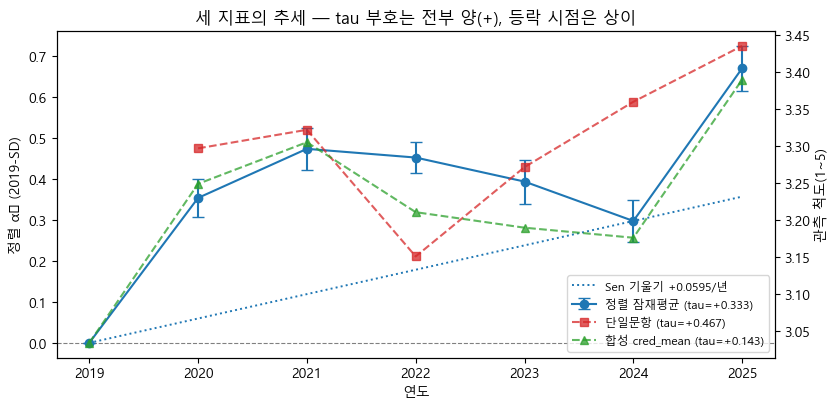

In [4]:
yrs_si = [2020, 2021, 2022, 2023, 2024, 2025]
si = T.weighted_year_mean(panel, "trust_news_overall", yrs_si)
mk_si = T.mann_kendall(si); sen_si = T.sens_slope(si, np.array(yrs_si, float))
comp = T.weighted_year_mean(panel.assign(cred_mean=panel[T.CORE3].mean(axis=1)),
                            "cred_mean", T.YEARS_ALL)
mk_co = T.mann_kendall(comp); sen_co = T.sens_slope(comp, np.array(T.YEARS_ALL, float))

xtab = pd.DataFrame({
    "지표": ["정렬 잠재평균", "단일문항 trust_news_overall", "합성 cred_mean"],
    "구간": ["2019~2025", "2020~2025", "2019~2025"],
    "tau": [mk_lat["tau"], mk_si["tau"], mk_co["tau"]],
    "정확 p": [mk_lat["p_exact"], mk_si["p_exact"], mk_co["p_exact"]],
    "Sen기울기(/년)": [sen_lat, sen_si, sen_co],
})
print(xtab.to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.errorbar(years, alpha, yerr=1.96 * alpha_boot.std(axis=0, ddof=1), fmt="o-",
            capsize=4, color="#1f77b4", label=f"정렬 잠재평균 (tau={mk_lat['tau']:+.3f})")
ax.plot(years, alpha[0] + sen_lat * (years - years[0]), ":", color="#1f77b4",
        lw=1.4, label=f"Sen 기울기 {sen_lat:+.4f}/년")
ax2 = ax.twinx()
ax2.plot(yrs_si, si, "s--", color="#d62728", alpha=.75,
         label=f"단일문항 (tau={mk_si['tau']:+.3f})")
ax2.plot(T.YEARS_ALL, comp, "^--", color="#2ca02c", alpha=.75,
         label=f"합성 cred_mean (tau={mk_co['tau']:+.3f})")
ax.set_xlabel("연도"); ax.set_ylabel("정렬 α̂ (2019-SD)"); ax2.set_ylabel("관측 척도(1~5)")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="lower right", fontsize=8.5)
ax.set_title("세 지표의 추세 — tau 부호는 전부 양(+), 등락 시점은 상이")
plt.tight_layout(); plt.show()

**관찰**: 세 지표의 **τ 부호가 모두 양(+)** (+0.333 / +0.467 / +0.143), Sen 기울기도 전부 양수 — 방향은 측정 방식에 둔감하다. p값은 전부 비유의(0.27~0.77)로 n=6~7의 저검정력을 다시 확인시킨다. 등락 *시점*은 지표마다 어긋나므로(23 §7과 동일 관찰) 합의는 **"방향: 상승"** 까지다.

**교차검정 — 완료**

## **5. APC 분해 — a + c = p 식별문제를 어떻게 푸는가**

APC의 근본 난점은 **완전 공선성**이다: 연령 = 기간 - 출생코호트. 세 효과를 같은 해상도로 넣으면 설계행렬이 rank 부족이 되어 무한 해가 존재한다. 본 파이프라인은 표준 대응 둘을 **삼각검증**으로 병행한다:

| 방법 | 발상 | 역할 |
|------|------|------|
| **HAPC-GLMM** (Yang & Land 2006) | 연령=고정 다항(2차), 기간·코호트=**교차분류 임의효과**(BLUP) — 수축으로 식별 | 주방법 |
| **Intrinsic Estimator** (Yang·Fu·Land 2004) | 편차코딩 설계행렬의 **최소노름해**(pinv) — 영공간 직교 성분만 추정 | 보조·삼각검증 |

**+ 간격차 완화**: 연령·코호트를 **5년군**, 기간을 **1년**으로 두면 선형 항등식이 정확히 성립하지 않아 식별이 부분 완화된다(Yang 2010). 실제로 IE 진단 rank_ok=True(null_dim=0) — 이 데이터에서 설계행렬은 full-rank다.

### **Decision Box ② — APC 산출변수와 2022 표본지배 처리**

**기준: 무엇을 종속변수로 놓고, 64.8% 쏠림(2022)을 어떻게 중화하는가.**

| 결정 | 선택 | 근거 |
|------|------|------|
| 산출변수 | **cred_mean**(3지표 단순평균, 1~5) | 21에서 **metric 동등 강지지** → 관계·구조 분석용 합성 정당. 잠재점수 대신 manifest 합성인 이유 = APC 프레임(개인 단위 회귀)에 잠재점수를 넣으면 측정오차 전파를 별도 모형화해야 — 범위 밖(한계로 명시) |
| 2022 처리(HAPC) | **6,000 하향표집**(고정 seed) | 임의효과는 셀 N에 수축이 비례 — 2022만 5.9만이면 기간 BLUP 균형 붕괴 |
| 2022 처리(IE) | **wt_year_eq 가중** | WLS라 가중으로 연도 기여 균등화 가능(하향표집 불필요, 정보 보존) |

같은 문제(표본지배)를 방법 특성에 맞게 **서로 다른 도구**로 중화한다 — 두 방법이 그런데도 같은 답을 내면(§6) 처리 방식의 인공물이 아니라는 방증이 된다.

## **6. [발견] APC 분해 — 기간(시대)이 추세를 주도하고, 코호트 구배가 공존한다**

In [5]:
frame = T.make_apc_frame(panel)                    # 2022 cap=6,000 (HAPC용)
print(f"APC 입력 N={len(frame):,} (age·birth_cohort·cred_mean 완전케이스, 2022 하향표집)")

hapc = T.hapc_mixed(frame)                          # HAPC-GLMM (연령 고정다항 + 교차 임의효과)
ie = T.intrinsic_estimator(frame)                   # IE (wt_year_eq 가중 최소노름해)
pe_h = np.array([hapc["period_re"].get(y, np.nan) for y in T.YEARS_ALL])
pe_i = np.array([ie["period"].get(y, np.nan) for y in T.YEARS_ALL])

r_hapc_align = np.corrcoef(pe_h, alpha)[0, 1]
r_ie_align = np.corrcoef(pe_i, alpha)[0, 1]
r_hapc_ie = np.corrcoef(pe_h, pe_i)[0, 1]

per_tbl = pd.DataFrame({"연도": T.YEARS_ALL, "정렬 α̂(23)": alpha,
                        "기간효과 HAPC(BLUP)": pe_h, "기간효과 IE": pe_i})
print(per_tbl.to_string(index=False))
print(f"\n기간효과 상관: HAPC-정렬추세 = {r_hapc_align:+.3f} · IE-정렬추세 = {r_ie_align:+.3f} "
      f"· HAPC-IE = {r_hapc_ie:+.3f}")
print(f"IE 식별 진단: rank_ok={ie['rank_ok']} (null_dim={ie['null_dim']})")

APC 입력 N=38,060 (age·birth_cohort·cred_mean 완전케이스, 2022 하향표집)


  연도  정렬 α̂(23)  기간효과 HAPC(BLUP)  기간효과 IE
2019      0.000           -0.206   -0.194
2020      0.354            0.003    0.026
2021      0.474            0.067    0.079
2022      0.453            0.014   -0.008
2023      0.394           -0.001   -0.027
2024      0.298           -0.053   -0.047
2025      0.671            0.176    0.171

기간효과 상관: HAPC-정렬추세 = +0.990 · IE-정렬추세 = +0.960 · HAPC-IE = +0.988
IE 식별 진단: rank_ok=True (null_dim=0)


**관찰 — 삼각검증 성립**: 전혀 다른 식별 전략(수축 vs 최소노름)·다른 2022 처리(하향표집 vs 가중)를 쓴 두 방법의 기간효과가 서로 r=+0.988로 겹치고, 둘 다 23의 정렬 잠재추세와 r=+0.990/+0.960으로 정합한다. **관측된 상승 = 기간(시대) 효과** — 노화나 표본 세대구성 변화로는 설명되지 않는다. Q2의 답이다.

이제 나머지 두 성분(연령·코호트)의 프로파일을 본다.

**[시각화] APC 3효과 프로파일** — 좌: 기간효과 2종 vs 정렬추세(각각 표준화, 형상 비교). 중: 연령효과(IE 편차). 우: 코호트효과(IE 편차, 소표본 N<200 셀은 ×표시·회색). 편차 스케일이 성분별로 다르니 **y축 범위**에 주목 — 코호트(약 0.8)·기간(약 0.4) 대비 연령(약 0.11)이 얼마나 납작한지가 두 번째 발견이다.

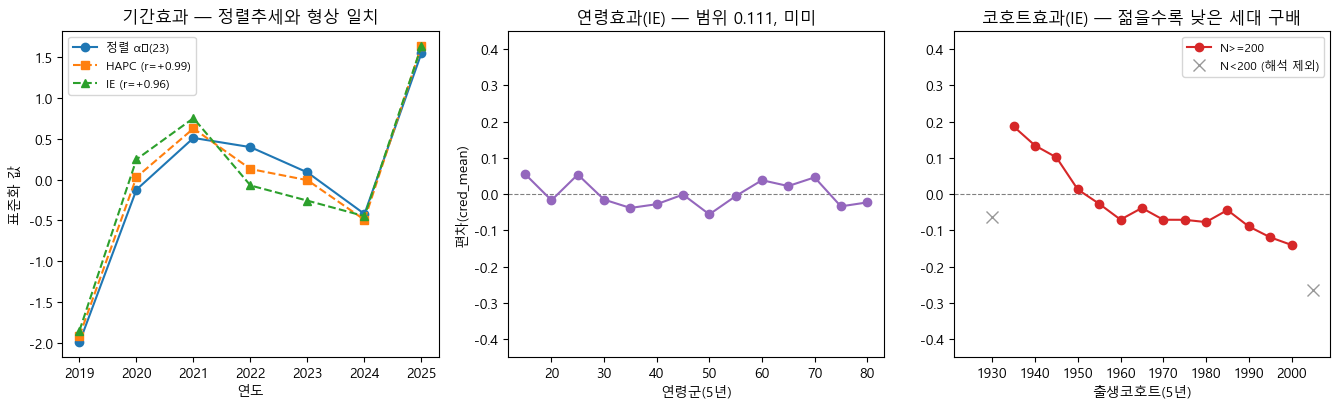

연령효과 편차 범위 = 0.111 (U자형, 중장년 저점)
코호트 기울기(출생연도-효과 상관, N>=200 셀) = -0.891


In [6]:
def z(v):
    v = np.asarray(v, float); return (v - v.mean()) / v.std(ddof=0)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
# (1) 기간 — 표준화 형상 비교
axes[0].plot(T.YEARS_ALL, z(alpha), "o-", color="#1f77b4", label="정렬 α̂(23)")
axes[0].plot(T.YEARS_ALL, z(pe_h), "s--", color="#ff7f0e", label=f"HAPC (r={r_hapc_align:+.2f})")
axes[0].plot(T.YEARS_ALL, z(pe_i), "^--", color="#2ca02c", label=f"IE (r={r_ie_align:+.2f})")
axes[0].set_title("기간효과 — 정렬추세와 형상 일치"); axes[0].set_xlabel("연도")
axes[0].set_ylabel("표준화 값"); axes[0].legend(fontsize=8.5)

# (2) 연령
ages = sorted(ie["age"]); avals = [ie["age"][a] for a in ages]
axes[1].axhline(0, color="gray", lw=0.8, ls="--")
axes[1].plot(ages, avals, "o-", color="#9467bd")
axes[1].set_ylim(-0.45, 0.45)   # 코호트와 동일 스케일 → 납작함 대비
axes[1].set_title(f"연령효과(IE) — 범위 {max(avals)-min(avals):.3f}, 미미")
axes[1].set_xlabel("연령군(5년)"); axes[1].set_ylabel("편차(cred_mean)")

# (3) 코호트 (소표본 구분)
coh_n = frame["cohort5"].value_counts().to_dict()
cohs = sorted(ie["cohort"]); cvals = [ie["cohort"][c] for c in cohs]
big = [c for c in cohs if coh_n.get(c, 0) >= 200]
axes[2].axhline(0, color="gray", lw=0.8, ls="--")
axes[2].plot([c for c in cohs if c in big], [ie["cohort"][c] for c in big],
             "o-", color="#d62728", label="N>=200")
axes[2].plot([c for c in cohs if c not in big], [ie["cohort"][c] for c in cohs if c not in big],
             "x", color="0.6", ms=8, label="N<200 (해석 제외)")
axes[2].set_ylim(-0.45, 0.45)
axes[2].set_title("코호트효과(IE) — 젊을수록 낮은 세대 구배")
axes[2].set_xlabel("출생코호트(5년)"); axes[2].legend(fontsize=8.5)
plt.tight_layout(); plt.show()

# 코호트 기울기(충분표본 셀만) · 연령 범위
cb = np.array(big, float); cv = np.array([ie["cohort"][c] for c in big])
coh_grad = float(np.corrcoef(cb, cv)[0, 1])
age_rng = max(avals) - min(avals)
print(f"연령효과 편차 범위 = {age_rng:.3f} (U자형, 중장년 저점)")
print(f"코호트 기울기(출생연도-효과 상관, N>=200 셀) = {coh_grad:+.3f}")

**관찰 — 두 번째 발견(이중 구조)**:

1. **연령효과는 미미하다**: 편차 범위 0.111(U자형, 중장년 저점) — 생애주기는 신뢰성 인식을 거의 움직이지 않는다. "나이 들면 언론을 더/덜 믿는다"는 통념은 이 데이터에서 근거가 없다.
2. **코호트 구배는 뚜렷하다**: 출생연도-효과 상관 **-0.891**(N≥200 셀). 1935~1949년생(+0.10~+0.19)에서 2000년대생(-0.14 이하)까지 사실상 단조 하락 — **젊은 세대일수록 언론 신뢰성 인식이 낮다**. 이것은 기간효과와 *독립인 구조적 세대차*다.

**함의(Q3)**: 현재의 상승 추세(기간효과)는 고신뢰 노년 코호트가 표본에 남아 있는 동안의 그림이다. 코호트 구배가 유지된 채 세대교체가 진행되면 **총평균에는 구조적 하방 압력**이 걸린다 — 추세 해석에 반드시 붙어야 할 단서다.

**APC 분해 — 완료**

## **8. 검증 셀 — `docs/design/trend-apc-results.md` 수치와 일치 (입증)**

SSOT 문서(§1~§3)에 박제된 수치를 재현하는지 assert로 입증한다. MK 정확 p는 순열분포(결정적), 부트스트랩·하향표집·HAPC는 고정 seed로 재현된다.

In [7]:
def close(a, b, atol=5e-3):
    return np.isclose(a, b, atol=atol)

# (a) MK 점추정 (문서 §1: S=7, tau=+0.333, 정확 p=0.3813, Sen=+0.0595)
assert mk_lat["S"] == 7 and close(mk_lat["tau"], 0.333, atol=1e-3)
assert close(mk_lat["p_exact"], 0.3813, atol=1e-3), mk_lat["p_exact"]
assert close(sen_lat, 0.0595, atol=1e-3), sen_lat

# (b) 불확실성 전파 (문서 §1: tau 평균 +0.415, P(S>0)=1.000)
assert close(taus.mean(), 0.415, atol=1e-2), taus.mean()
assert s_pos == 1.0, s_pos

# (c) 교차검정 tau 부호 3종 일치 (문서 §1.1: +0.467 / +0.143)
assert close(mk_si["tau"], 0.467, atol=1e-3) and close(mk_co["tau"], 0.143, atol=1e-3)
assert mk_lat["tau"] > 0 and mk_si["tau"] > 0 and mk_co["tau"] > 0

# (d) APC 삼각검증 (문서 §2.1: +0.990 / +0.960 / +0.988) + 식별 진단
assert close(r_hapc_align, 0.990, atol=1e-2) and close(r_ie_align, 0.960, atol=1e-2)
assert close(r_hapc_ie, 0.988, atol=1e-2)
assert ie["rank_ok"] and ie["null_dim"] == 0
assert len(frame) == 38060, len(frame)

# (e) 연령 미미·코호트 구배 (문서 §2.2~2.3: 범위 0.111, 기울기 -0.891)
assert close(age_rng, 0.111, atol=5e-3), age_rng
assert close(coh_grad, -0.891, atol=1e-2), coh_grad

# (f) 2025 기간효과가 7개년 최고 (문서 표1: HAPC +0.176 / IE +0.171)
assert np.nanargmax(pe_h) == len(T.YEARS_ALL) - 1 and np.nanargmax(pe_i) == len(T.YEARS_ALL) - 1
assert close(pe_h[-1], 0.176, atol=1e-2) and close(pe_i[-1], 0.171, atol=1e-2)

print("[검증 PASS] MK(S=7·p=0.3813·Sen+0.0595)·P(S>0)=1.00·교차 tau 3종·APC 상관 3종·"
      "연령범위 0.111·코호트 -0.891 — 문서 수치 재현")
print("           → '상승=기간효과 + 세대 구배 공존' 이중 발견이 재현 가능한 산출임을 입증")

[검증 PASS] MK(S=7·p=0.3813·Sen+0.0595)·P(S>0)=1.00·교차 tau 3종·APC 상관 3종·연령범위 0.111·코호트 -0.891 — 문서 수치 재현
           → '상승=기간효과 + 세대 구배 공존' 이중 발견이 재현 가능한 산출임을 입증


## **9. 종합 — 추세의 '성격'과 '정체'가 확정됐다**

### **9-1. 연구 질문 답**
- **Q1(통계적 성격)**: 점추정 MK는 **비유의(정확 p=0.381)** — n=7·비단조의 정직한 한계. 그러나 추정 불확실성을 전파하면 **P(S>0)=1.00** — "증가 방향" 판단은 표집 변동에 견고. 크기는 Sen +0.0595/년(참고치).
- **Q2(정체)**: **기간(시대) 효과가 주도** — HAPC·IE 기간효과가 정렬추세와 r=+0.990/+0.960, 상호 +0.988(삼각검증). 노화·세대구성 변화가 만든 가짜 추세가 아니다.
- **Q3(세대 구배)**: 연령효과는 미미(범위 0.111)하나 **코호트 구배 -0.891** — 젊은 세대일수록 낮은 신뢰성 인식. 세대교체가 진행되면 총평균에 **하방 압력**.

### **9-2. 단계별 요약**

| 단계 | 산출 | 판정 |
|------|------|:--:|
| 자기검증(MK·APC 시뮬) | 판정 정확·기간효과 회복 corr>0.95 | 직접구현 면허 |
| MK + 불확실성 전파 | p=0.381 / P(S>0)=1.00 | 방향 견고·크기 유보 |
| 교차검정 3지표 | τ 부호 전부 양(+) | 측정에 둔감 |
| APC 삼각검증 | 기간-정렬추세 r ≥ +0.96 | **상승 = 시대 효과** |
| 코호트 프로파일 | 구배 -0.891 (N≥200 셀) | **세대 하방 압력** |

### **9-3. 다음 단계**
P4 모델링 체인(21 측정동등 → 22 외부검증 → 23 추세 정당화 → 24 추세 분해)이 완결됐다. 남은 것은 P5 —
[`30-evaluation.ipynb`](30-evaluation.ipynb): 전 단계 증거를 **증거 사다리·삼각검증**으로 종합하고 무엇이 보고 가능한 결론인지 최종 판정한다.

### **Decision Box ③ — 해석 경계: p=0.381을 숨기지 않는다**

**기준: 통계적 정직성과 실질적 결론 사이의 선을 어디에 긋는가.**

| 주장 | 허용? | 근거·조건 |
|------|:--:|------|
| "신뢰성 잠재평균은 증가 **방향**" | ✅ | P(S>0)=1.00 + 교차 3지표 부호 일치 |
| "상승은 **시대(기간) 효과**" | ✅ | HAPC·IE 삼각검증 r ≥ +0.96 |
| "젊은 코호트일수록 신뢰 낮음" | ✅ | 구배 -0.891 (소표본 셀 제외 후) |
| "**유의한** 단조 증가 추세" | ❌ | 점추정 정확 p=0.381 — 이 표현은 금지 |
| "연 +0.06 SD씩 오른다"(크기 단정) | ⚠️ 참고치만 | Sen은 n=7 중앙값 — 구간 보고 없이 단독 인용 금지 |
| APC 효과의 절대값 해석 | ⚠️ 형상·순위만 | 완전식별 불가(간격차 부분완화) — 수준은 식별 가정 의존 |
| 보고서·웹데모 직접 인용 | ⏸ 게이트 | KPF 원자료 재검증(`data-spec.md §6`) 후 |

**왜 이 줄이 중요한가**: 이 노트북의 설득력은 "유의하다"는 주장이 아니라, **비유의 p를 그대로 보고하면서도** 방향·정체·구배가 견고함을 다층 증거로 쌓은 데서 나온다. p=0.381을 숨기면 나머지 전부가 의심받는다.

## **10. `src/trend_apc.py` 코드리뷰 결론**

**코드리뷰 — 통과(결함 없음)**:
- **MK 정확분포**: n≤8은 순열 전수(7!=5,040)로 정확 p — 소표본에서 정규근사 대신 정확검정, 동률보정 분산·연속성보정 z도 표준식. ✔
- **Sen 기울기**: 모든 연도쌍 기울기의 중앙값 — 이상연도 강건, t 간격 반영. ✔
- **불확실성 전파의 설계**: `alignment.py`의 부트스트랩을 **재사용**(재구현 0)해 α 분포에 MK 적용 — 파이프라인 간 정합(같은 식별·같은 가중). ✔
- **HAPC 사양**: 연령 고정 2차(중심화·10년 단위) + `vc_formula` 교차분류 임의효과(기간·코호트) — Yang & Land(2006) 표준 사양, ML(reml=False)로 BLUP 추출. ✔
- **IE 구현**: 편차(effect) 코딩 + 가중 pinv 최소노름해 — Yang·Fu·Land(2004) 정의 그대로, SVD로 null_dim 진단까지 노출(rank_ok). ✔
- **2022 이중 처리**: HAPC=하향표집(고정 seed)·IE=wt_year_eq 가중 — 방법 특성별 중화 후 결과 일치(+0.988)로 처리 인공물 배제. ✔
- **자기검증 2종**: MK 3패턴 판정 + APC 알려진 효과 회복 — 직접구현 리스크를 입증으로 상쇄. ✔
- → **결함 없음. 강제 수정 없이 리뷰 통과**(과잉수정 금지 원칙).

**다음**: [`30-evaluation.ipynb`](30-evaluation.ipynb) — P2~P4 전 증거를 사다리로 종합하는 P5 평가.